# Edit V2：概念核心编辑出题与流水探测

固定概念资料与正例 → agentmap + Codex 出题／原图构造 → 本地 Qwen-Image-2.1 作答 → malasci/gpt-6-astra（xhigh）联合评审。

本页默认不调用模型。第 2 格集中配置，第 3 格调用唯一正式入口。最后一格可在新 kernel 中独立运行：按固定结果快照生成可搜索、筛选、翻页和放大图片的浏览页，依次展示题面与考点、出题材料、检索候选与附图回执、原图构造和验收、最终原图与作答对照、逐项评审。失败、未附图和未执行单独说明；查看不会重跑模型或补做检索。


In [ ]:
# 图片输入须有 image_uri，场景池须有 object_ref={uri,sha256}；先迁移旧表，再填实际固定版本。
from pathlib import Path
import sys
import os
# 本机 4001 网关无需客户端密钥；仅补客户端要求的非空默认值。
os.environ.setdefault('MODELHUB_API_KEY', 'anything')
import json
import lance
import pandas as pd
from IPython.display import display, Image as DisplayImage, Markdown

# 从项目根或 notebook 目录均可使用；唯一执行入口在正式 Python pipeline。
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents, Path.cwd() / 'demiwtg') if (p / 'project.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from project import resolve_root
from demiflow import data
from benchmark.edit.v2.edit_v2_benchmark_pipeline import config, run_pipeline, DATASETS
from benchmark.edit.v2.operators.images import image_object_ref, image_bytes

RUN_ID = 'edit_e2e10_v1_20261004'
COHORT_SOURCE = {
    'uri': str(resolve_root() / 'demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_common100_priority_20261004.lance'),
    'version': 4,
}
SAMPLE_SIZE = 10
SAMPLE_SEED = 20260928
ARTICLE_SOURCE = None
VISUAL_SOURCE = None  # 概念定义、文档与审核正例统一来自固定 COHORT_SOURCE。
AGENT_CONFIG = REPO / 'benchmark/edit/v2/prompts/agent_codex.yaml'
# 模型、工具、预算、原图生成开关和正文均在上述单份完整配置中维护。
DOCUMENT_RESOURCES = {}  # 可选：概念 → 材料编号 → {document_ref: {uri: 本地 file URI, sha256: 摘要}, url: 来源链接}；Codex 收到本地路径。
MAX_GENERATION_ATTEMPTS = 2  # 作者需遵守的图像工具尝试次数；不是后端强制配额。
MAX_CALLS = SAMPLE_SIZE  # 新增 Codex 会话上限；不是内部模型/工具调用数。
CONCURRENCY = 2
QUEUE_DEPTH = 1
MAX_REFERENCE_IMAGES = 5
PROGRESS_EVERY = 1  # 每 N 个完成结果打印；无结果时不产生定时心跳。
WRITE_MODE = 'overwrite'
THROUGH = 'probe'  # 'author' 只交付题目；'probe' 在出题过程中接作答和一次评审。
PROBE = {
    'model': 'Qwen-Image-2.1',
    'base_url': 'http://127.0.0.1:8005/v1',  # 需部署支持 JSON /images/edits 的本地服务。
    'revision': 'local-qwen-image-2.1-edit-json-v1',  # 部署身份标签；换权重/实现须修改，不代表已冻结权重。
    'steps': 40, 'image_size': '1024x1024', 'run_seed': 0,
    'concurrency': 1, 'queue_depth': 1, 'timeout_s': 600,
    'max_generation_calls': SAMPLE_SIZE,
    'review_concurrency': 1, 'review_queue_depth': 1,
    'max_review_calls': SAMPLE_SIZE, 'review_reasoning_effort': 'xhigh',
}
RUN_PIPELINE = False

CONFIG = config(
    run=resolve_root() / DATASETS / RUN_ID, cohort_source=COHORT_SOURCE,
    sample_size=SAMPLE_SIZE, sample_seed=SAMPLE_SEED,
    article_source=ARTICLE_SOURCE, visual_source=VISUAL_SOURCE,
    target_uri=None, write_mode=WRITE_MODE, agent_config=AGENT_CONFIG,
    document_resources=DOCUMENT_RESOURCES, max_generation_attempts=MAX_GENERATION_ATTEMPTS,
    max_calls=MAX_CALLS, max_reference_images=MAX_REFERENCE_IMAGES,
    concurrency=CONCURRENCY, queue_depth=QUEUE_DEPTH, progress_every=PROGRESS_EVERY,
    through=THROUGH, probe=PROBE if THROUGH == 'probe' else None,
)
print('本次配置（尚未执行）：')
display(CONFIG)


In [ ]:
# 唯一正式入口。同步调用避免中断 notebook 后遗留后台写表线程。
if RUN_PIPELINE:
    state = run_pipeline(CONFIG)
    display(state)
else:
    print('未调用模型。需要执行时将 RUN_PIPELINE 改为 True 后运行本格；会使用 Codex，并按 THROUGH 调用本地编辑与 GPT 评审。')



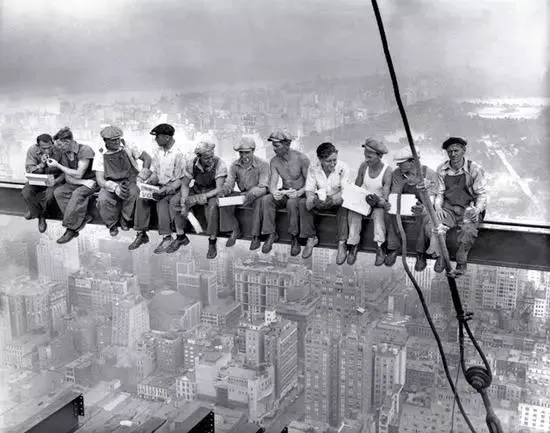
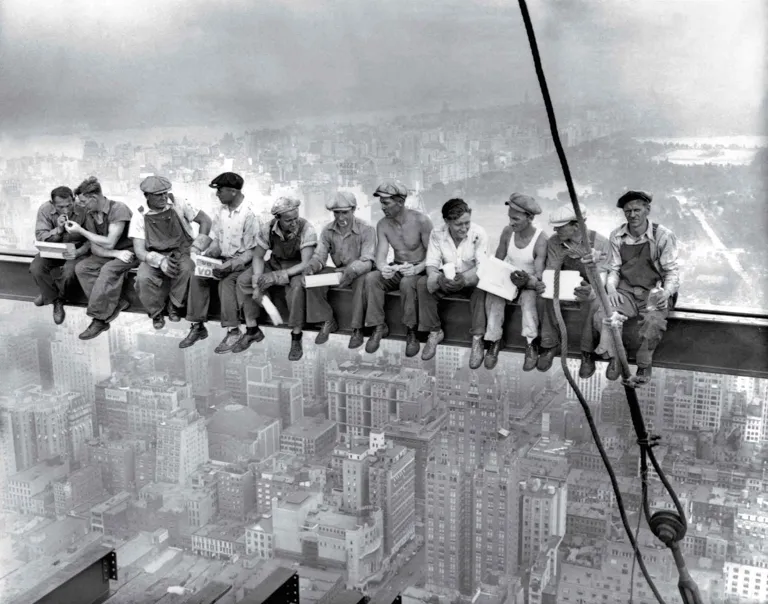
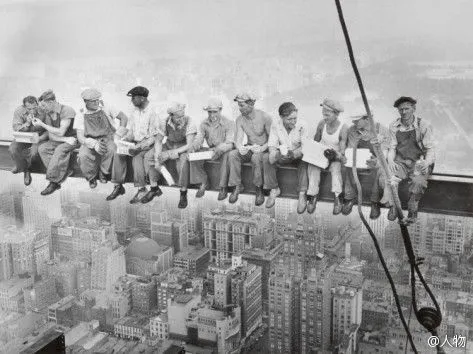
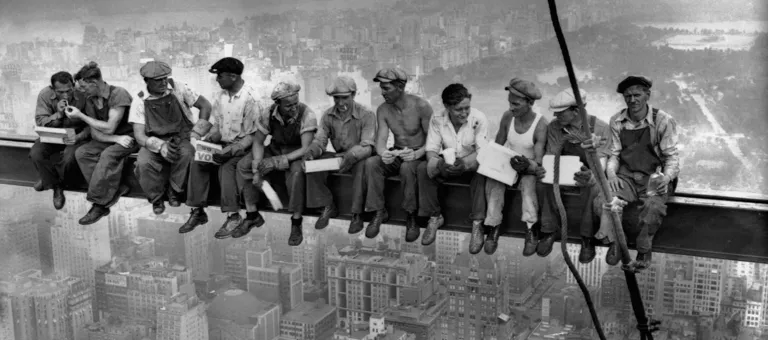
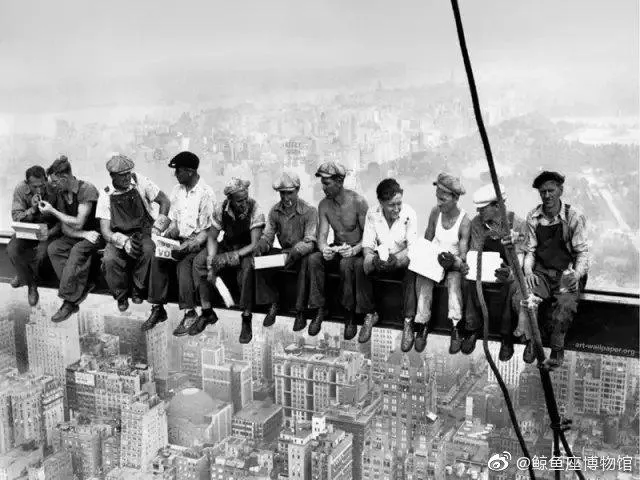
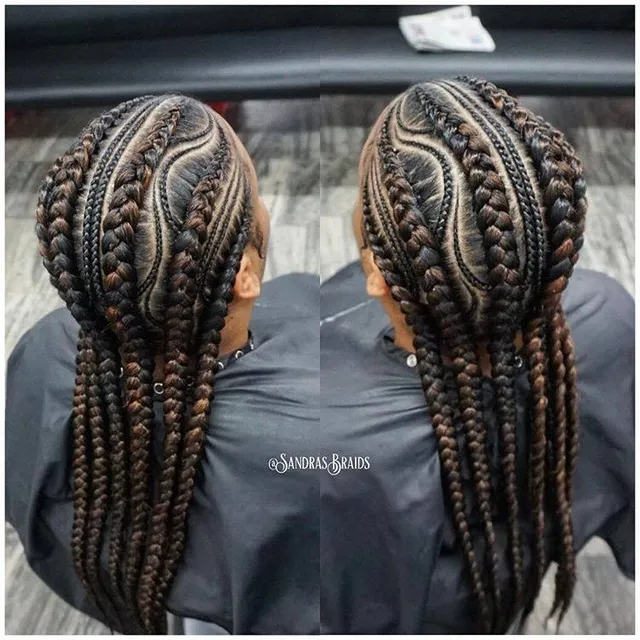
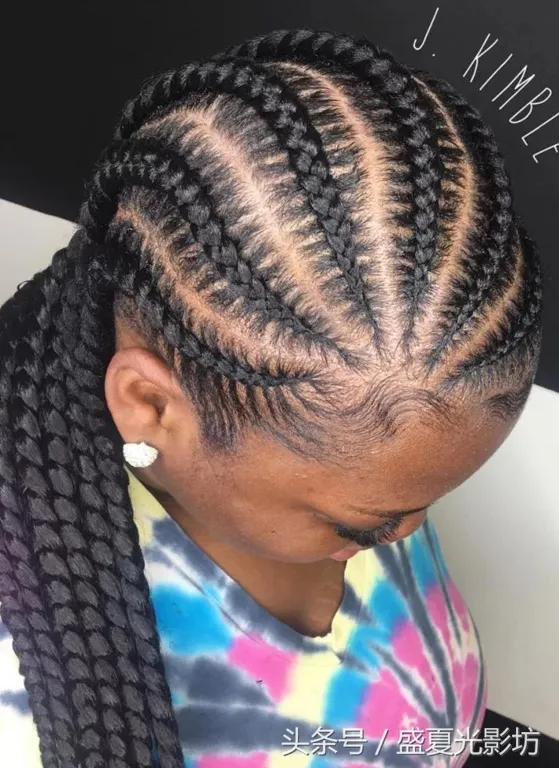
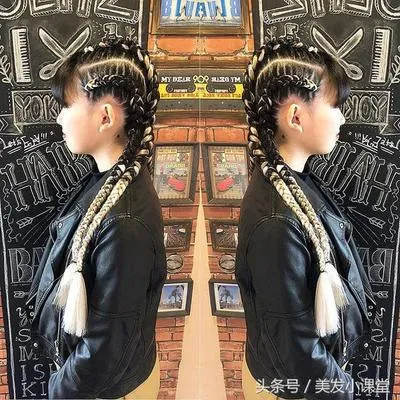
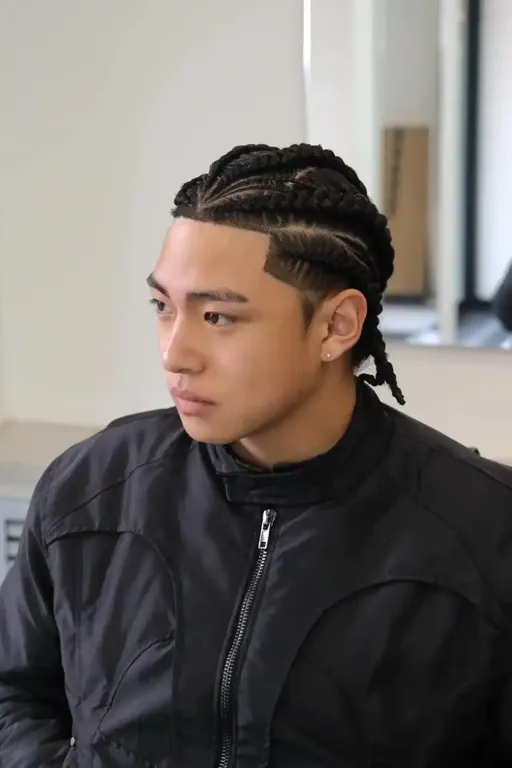
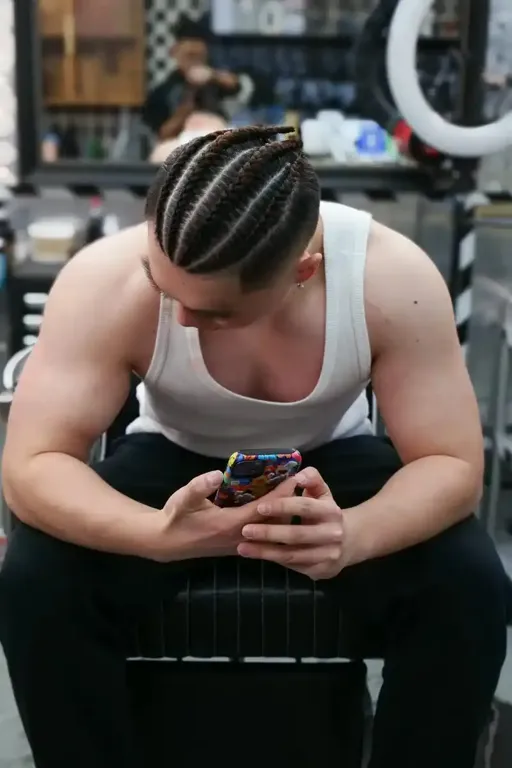
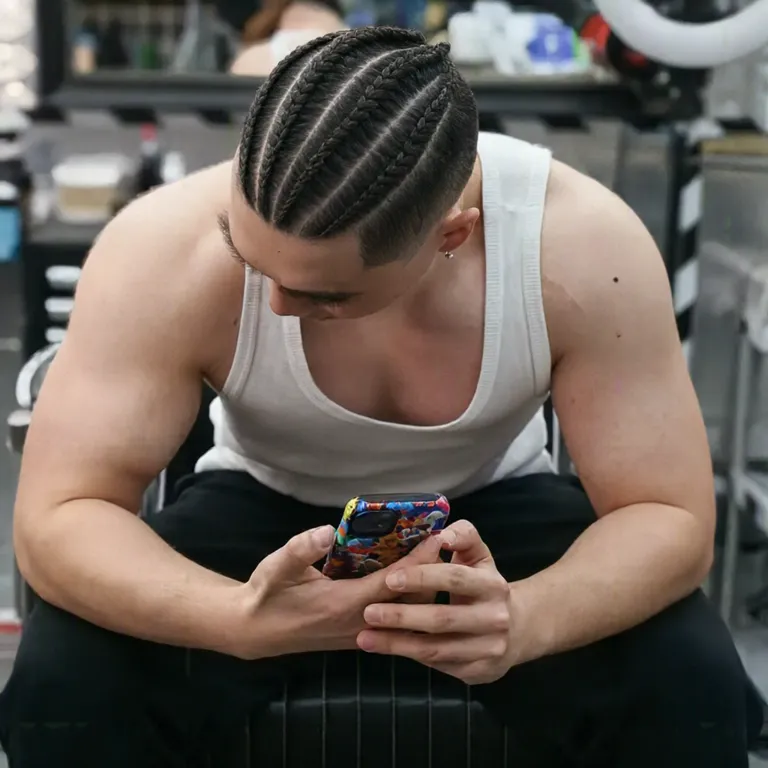
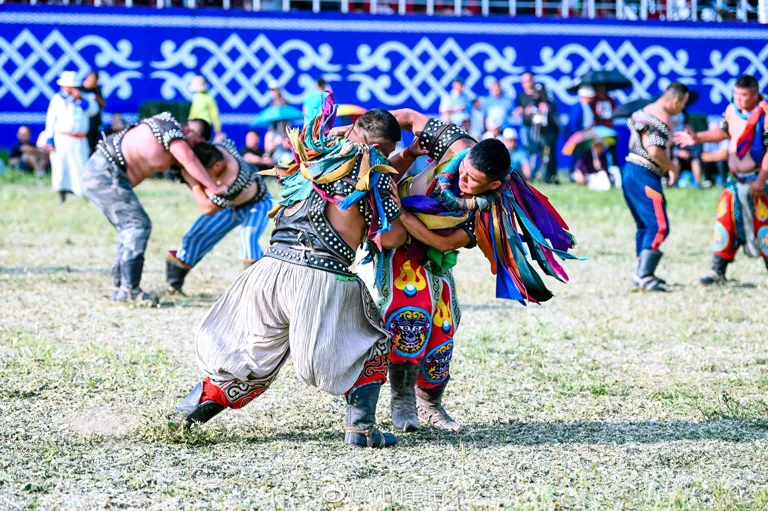
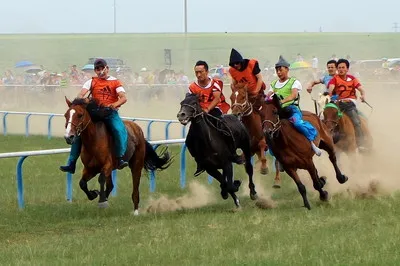
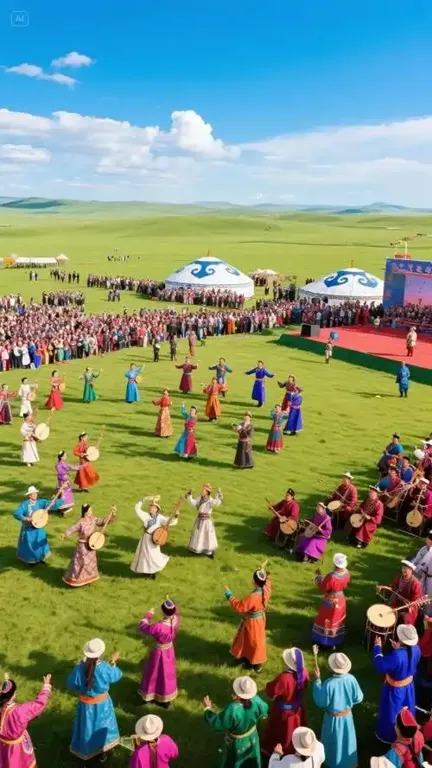
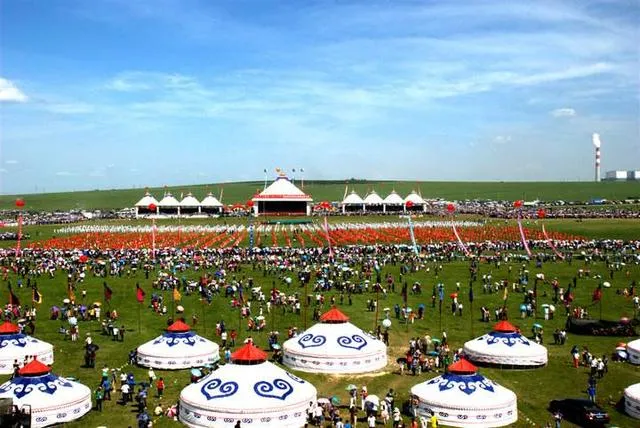
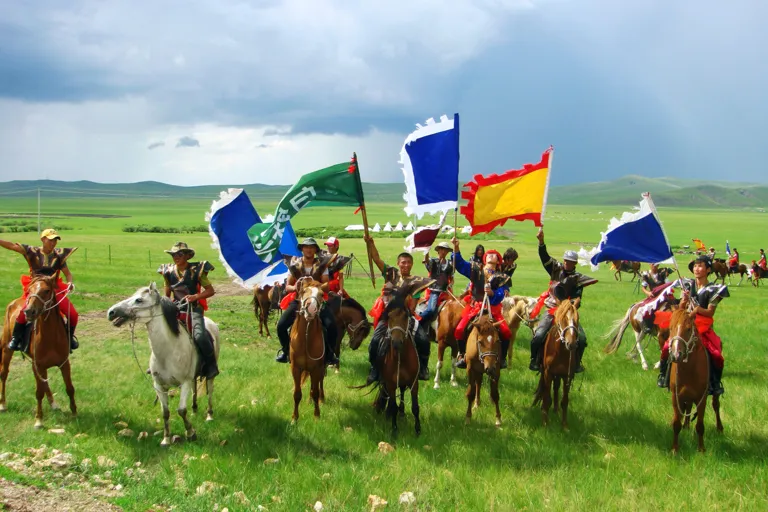
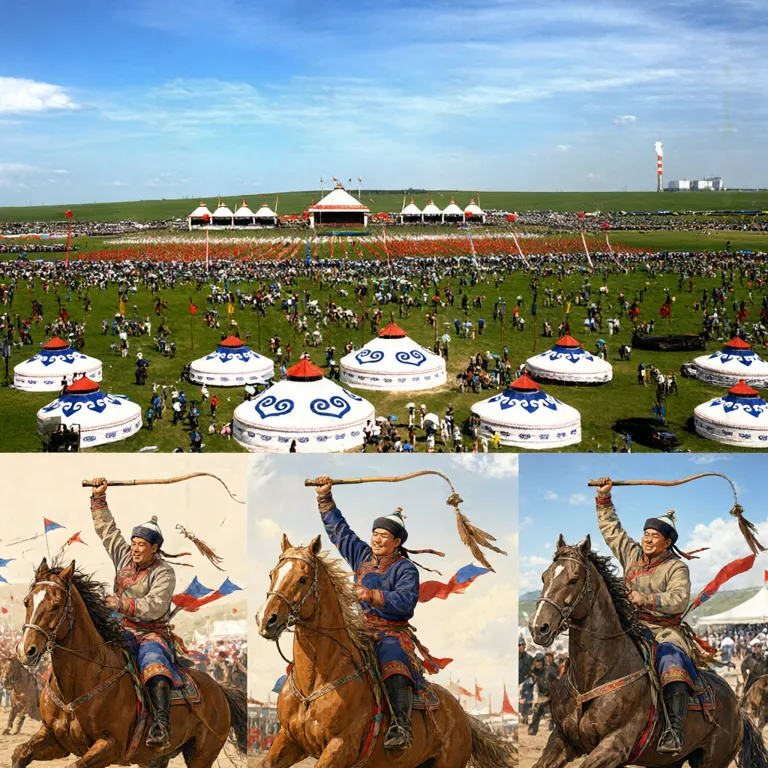
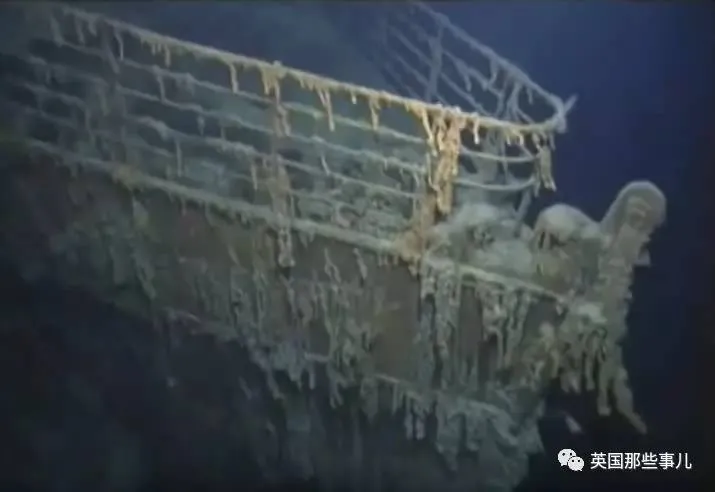
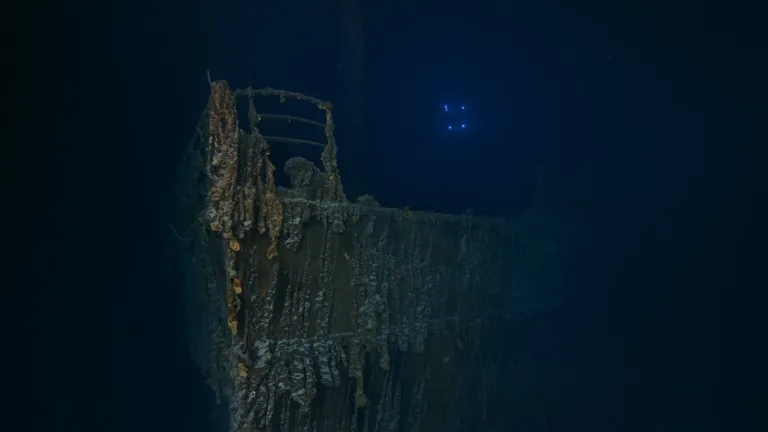
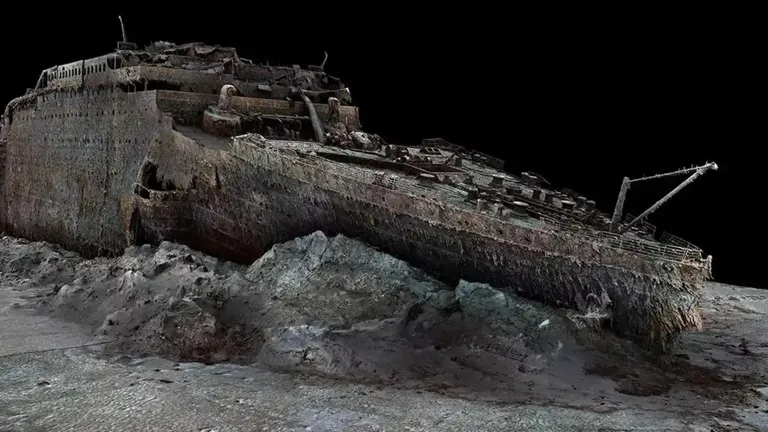
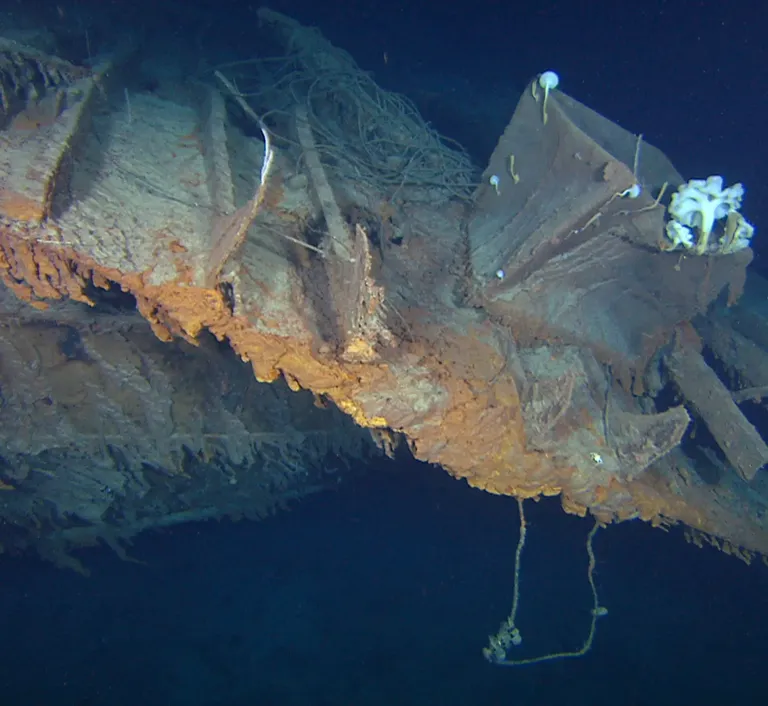
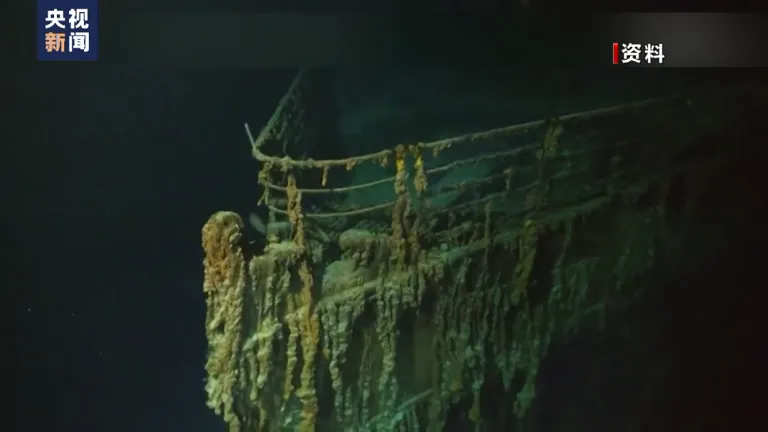
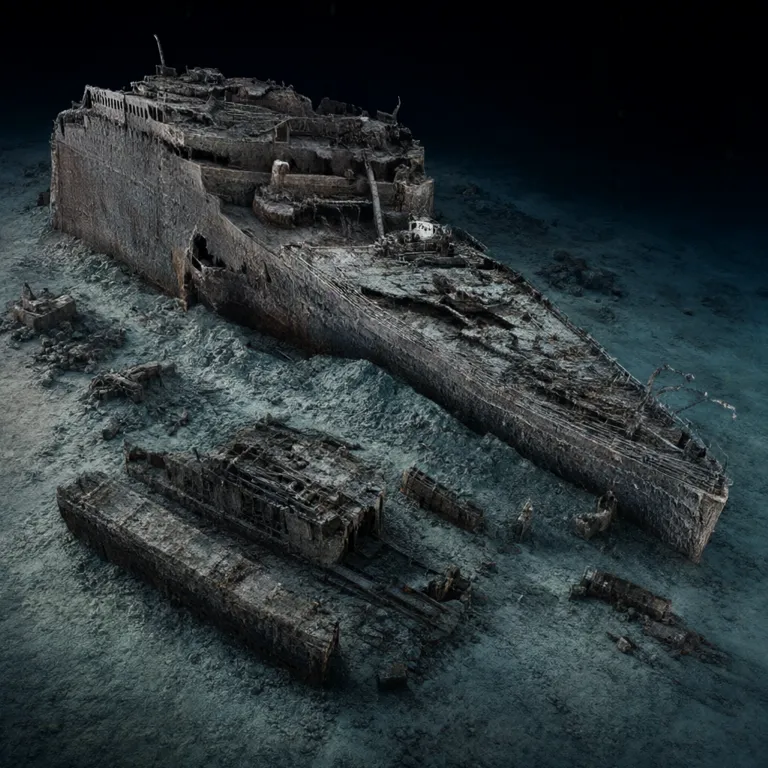
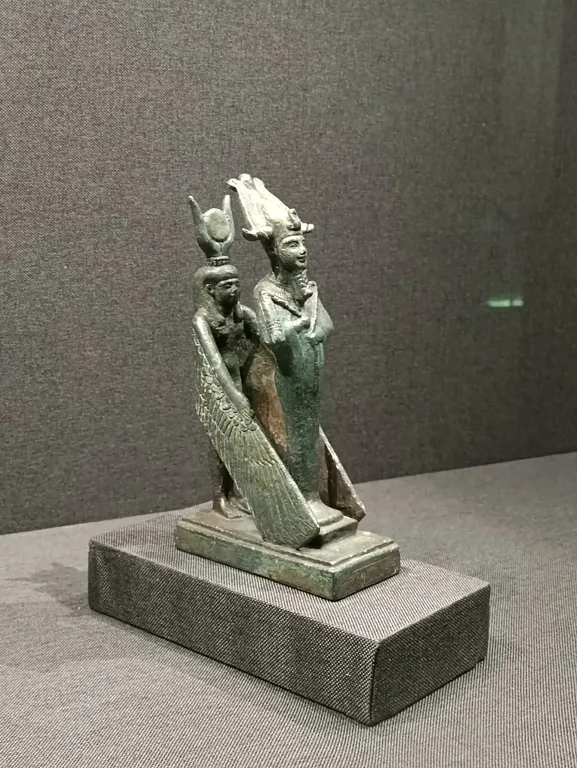
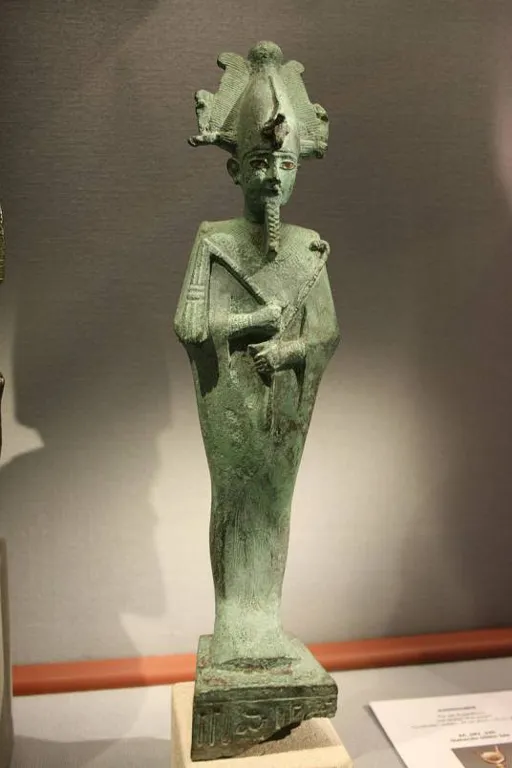
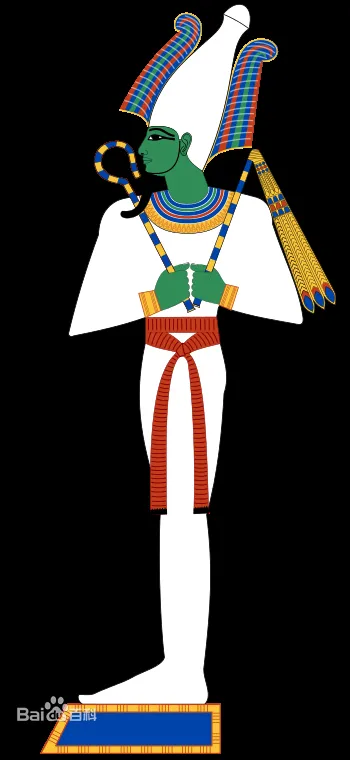
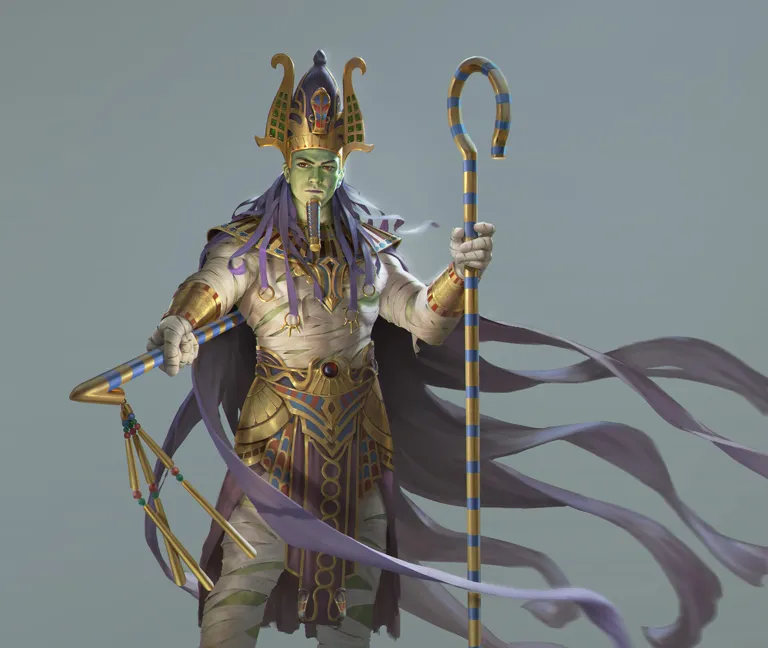
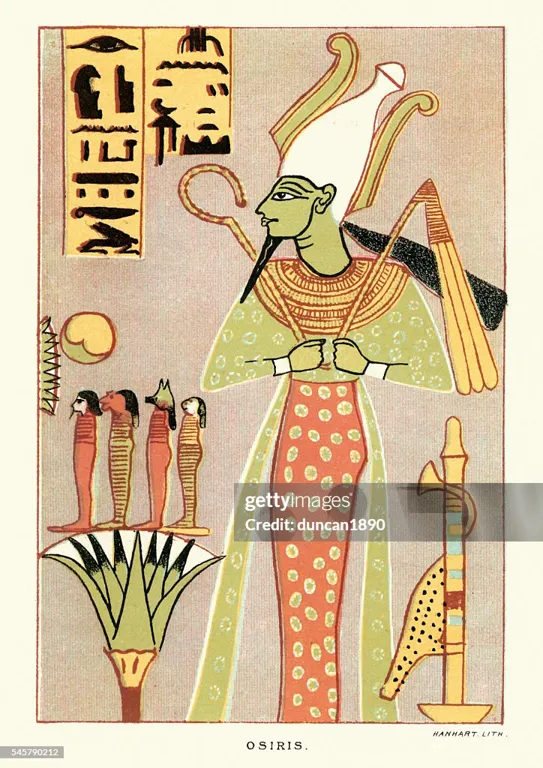
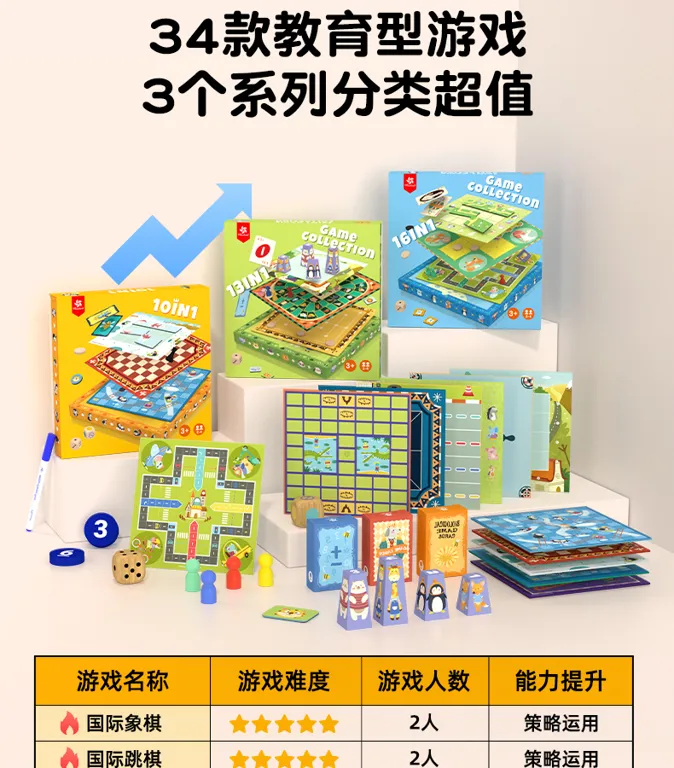
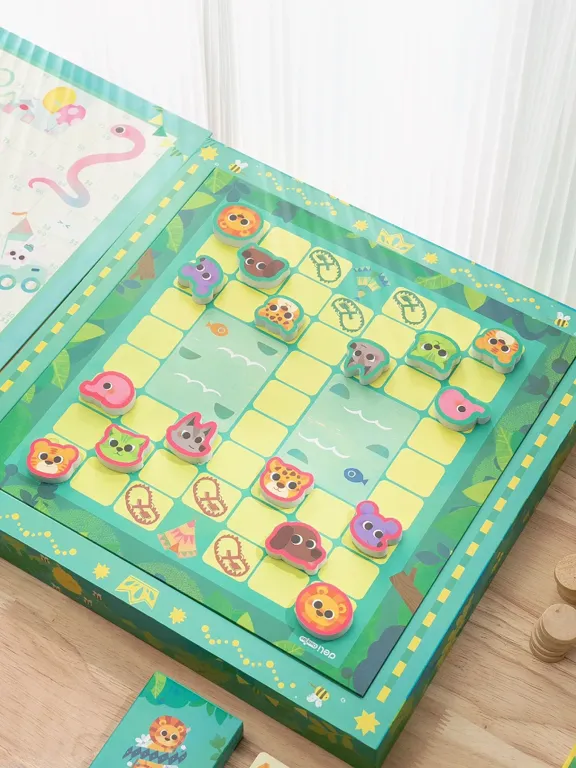
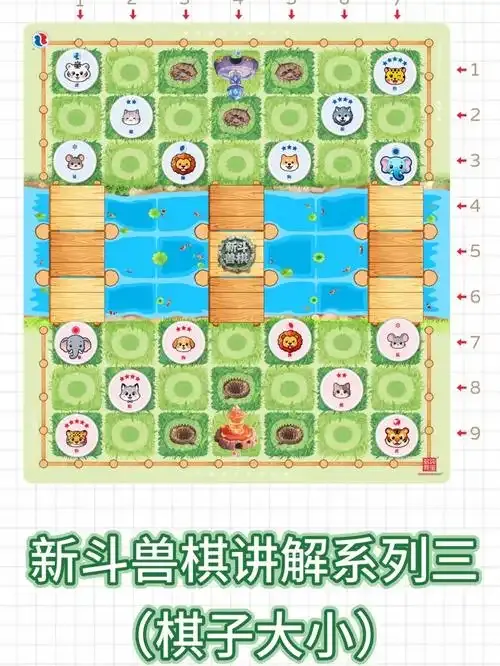
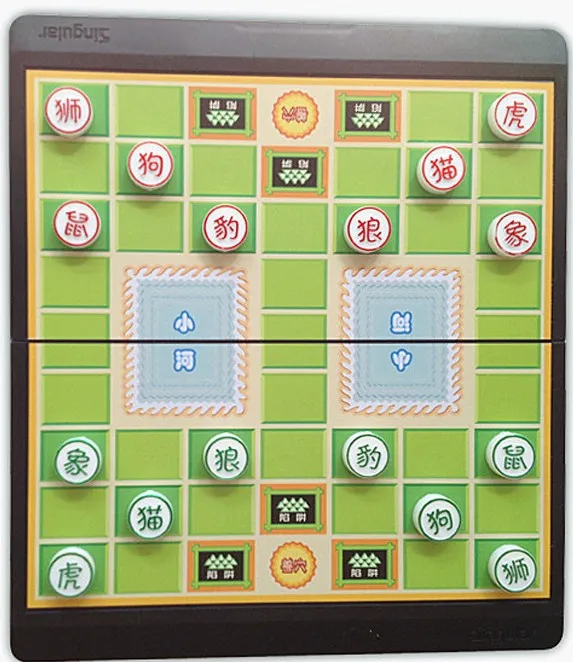
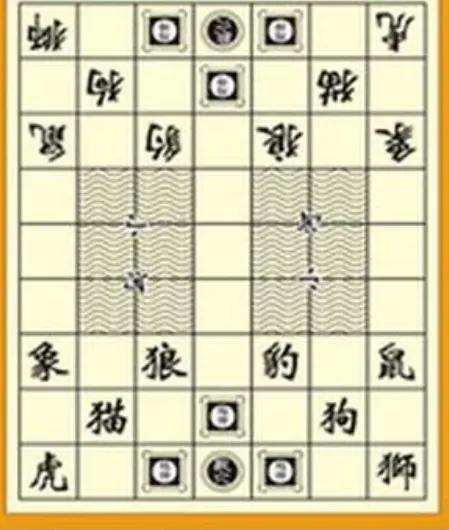
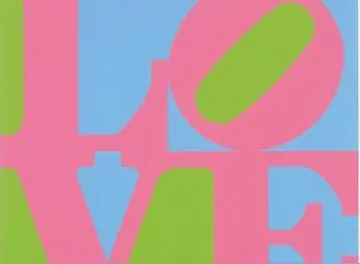
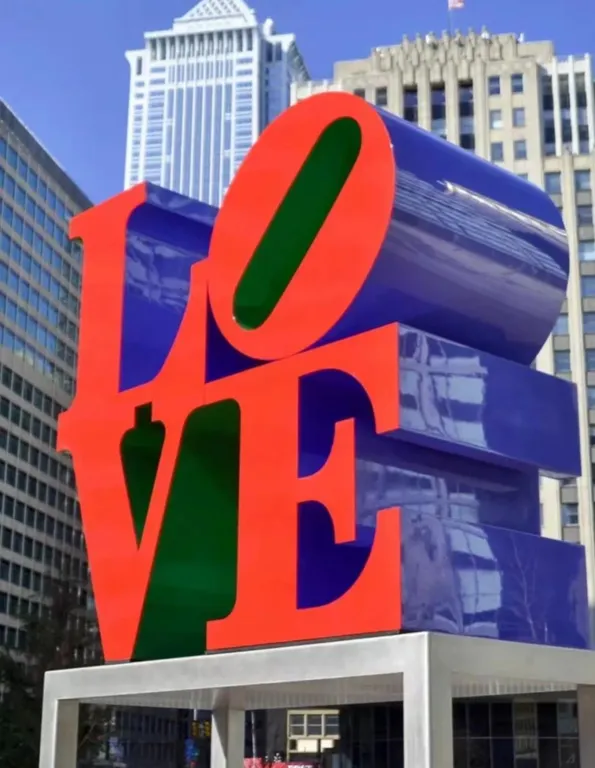
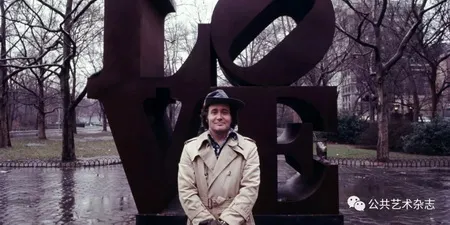
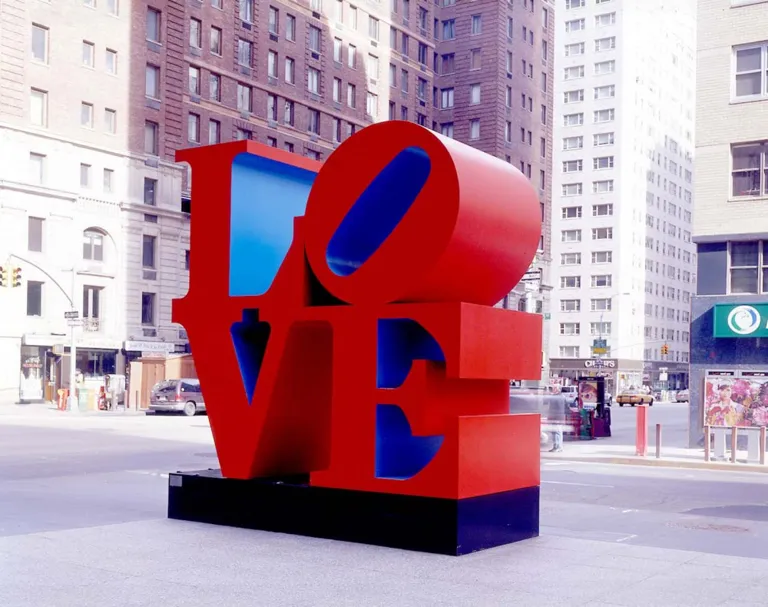
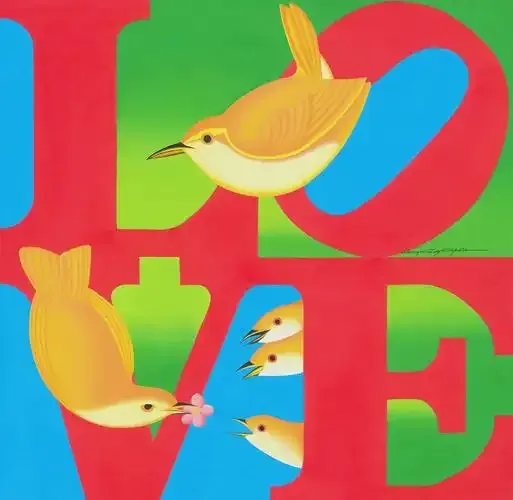
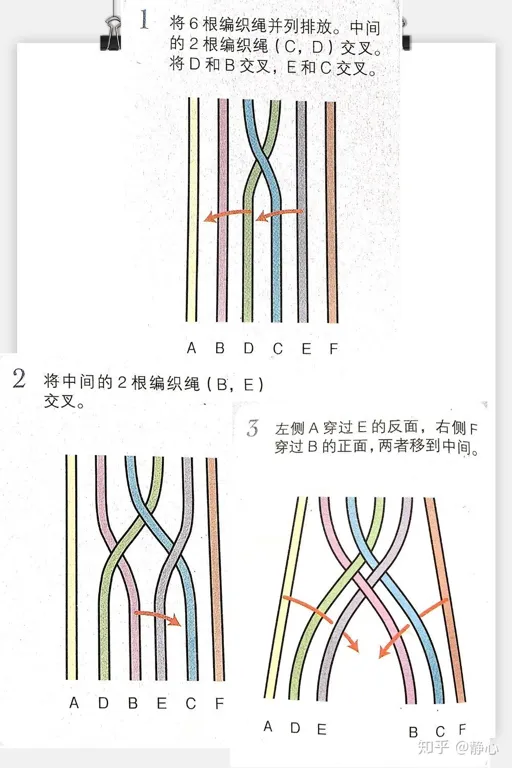
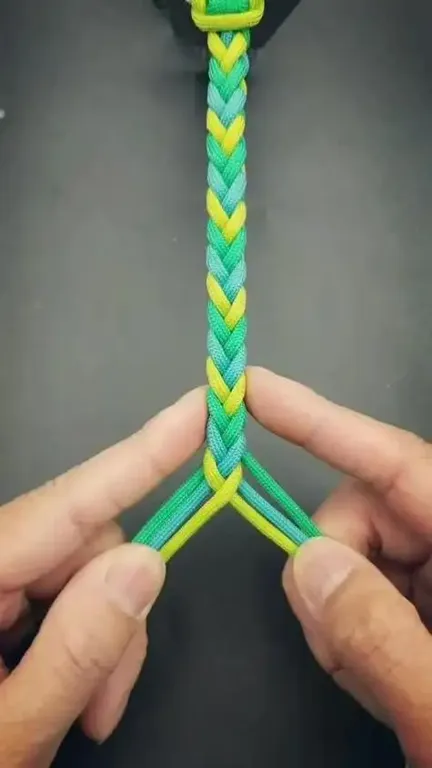
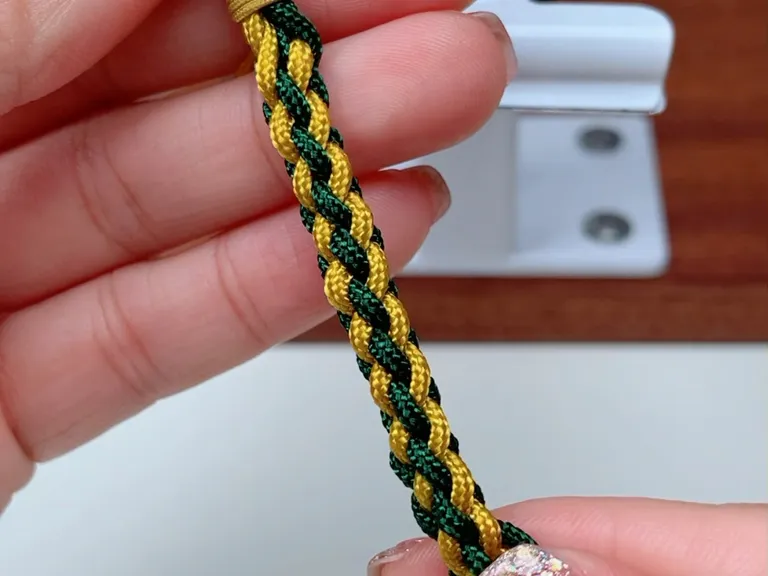
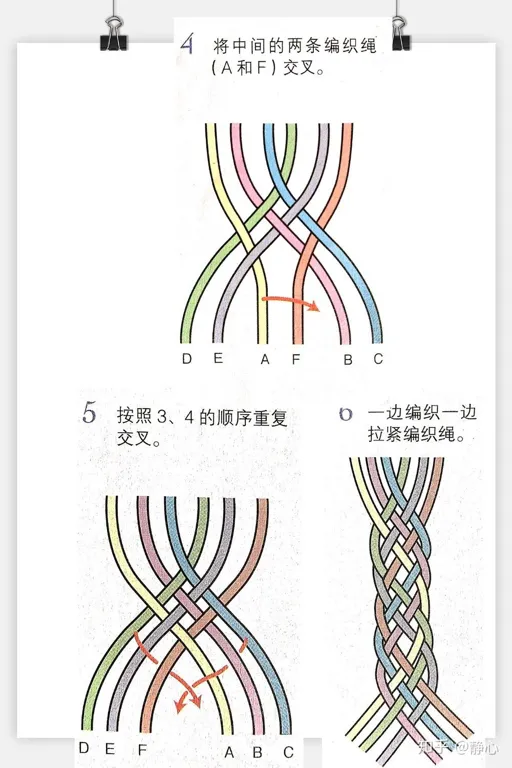
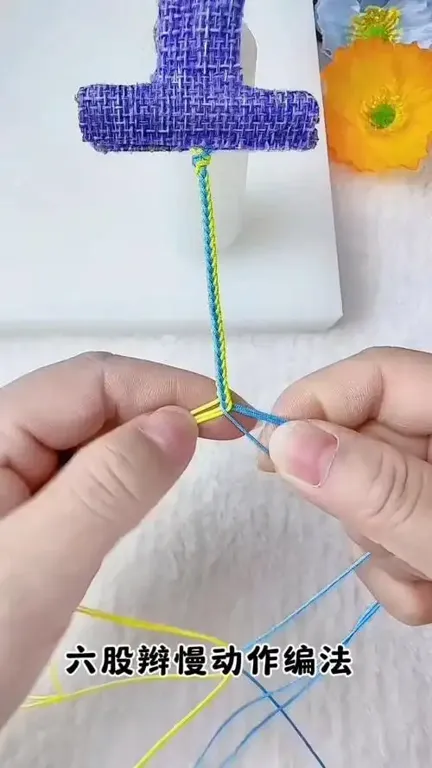
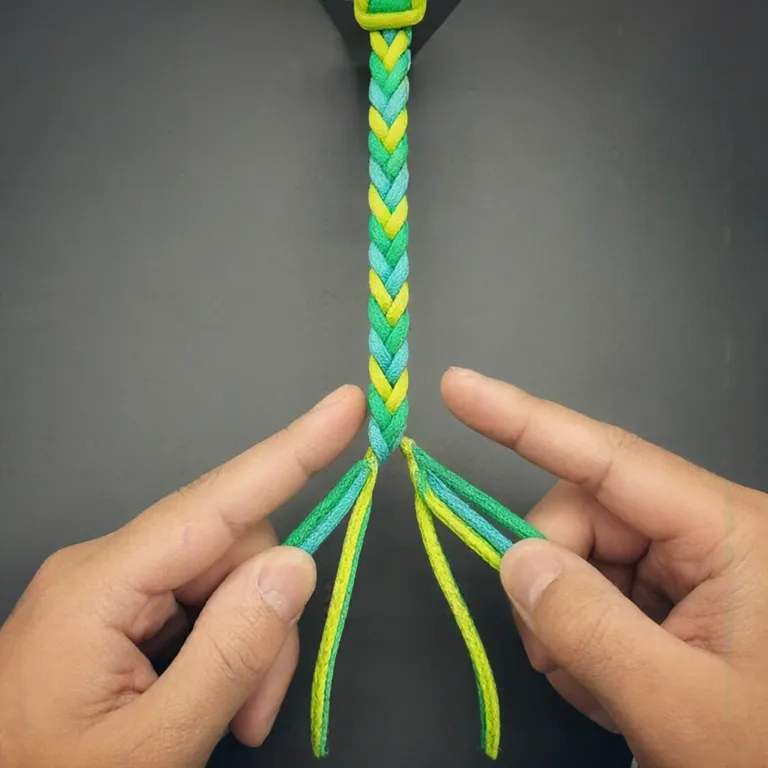
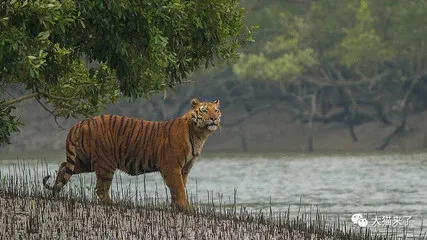
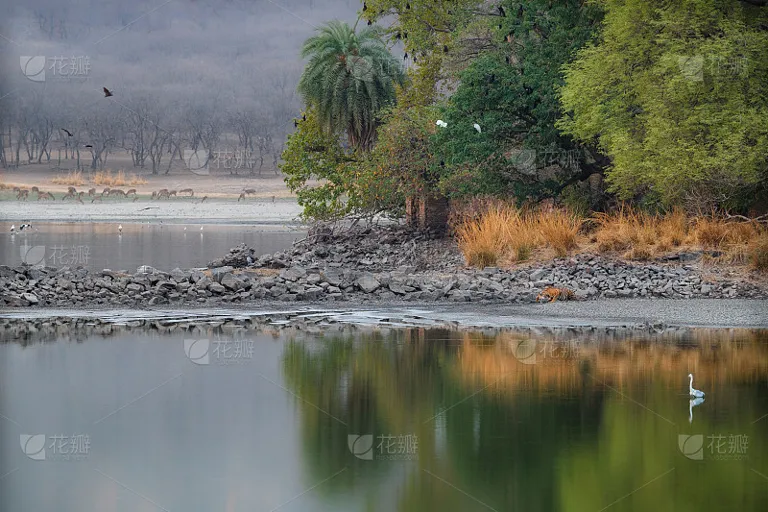
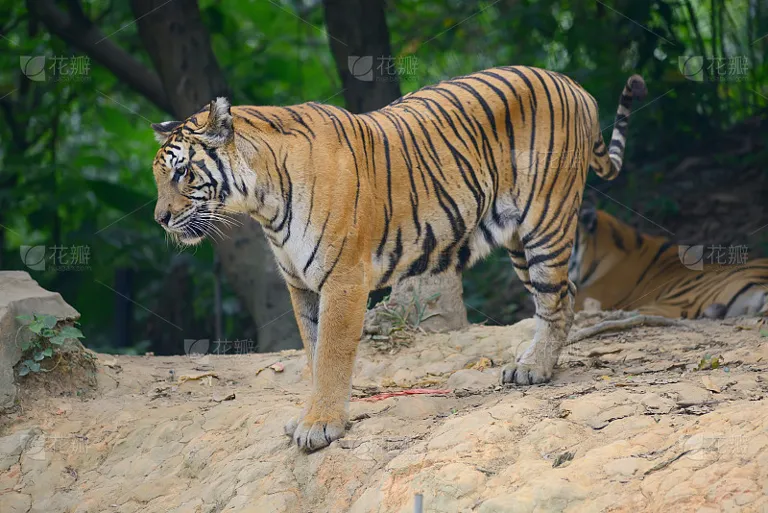
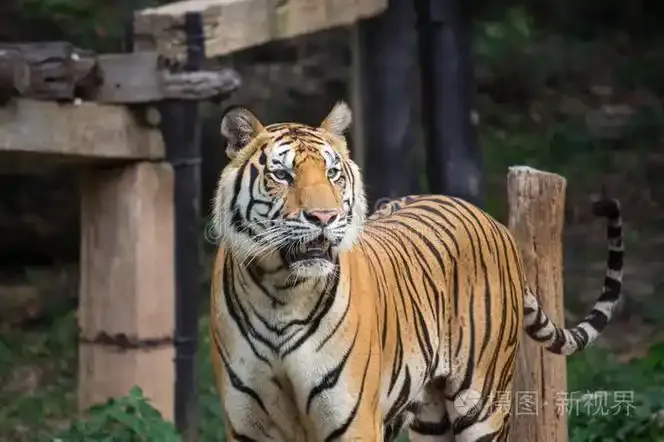
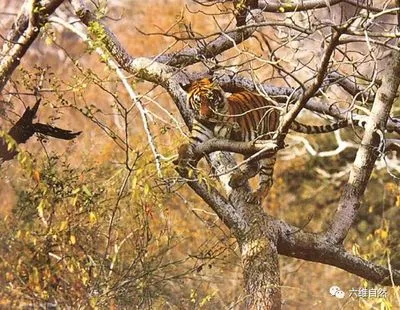
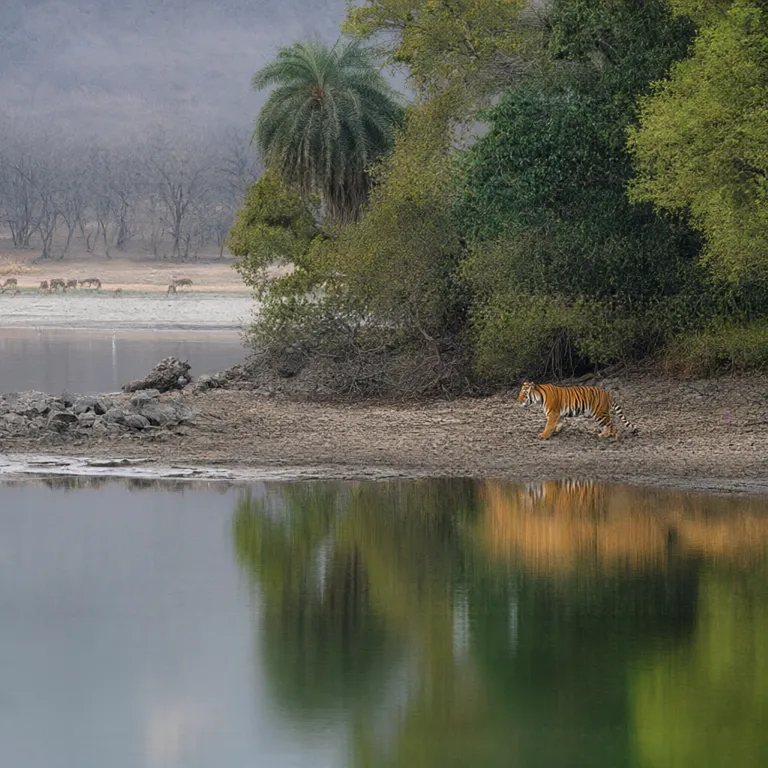
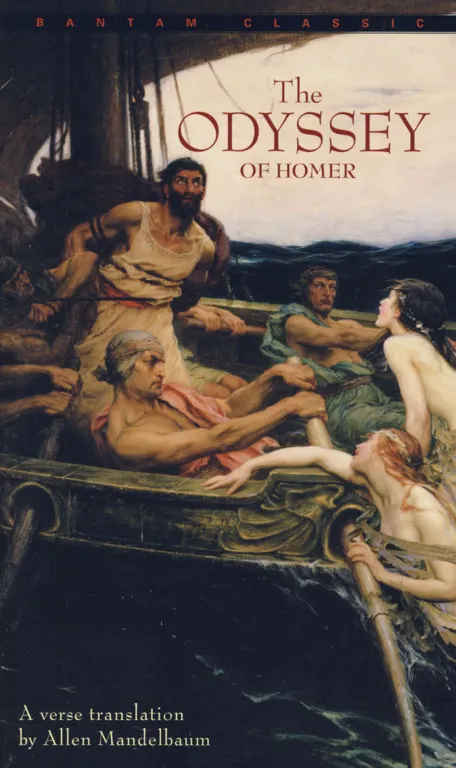
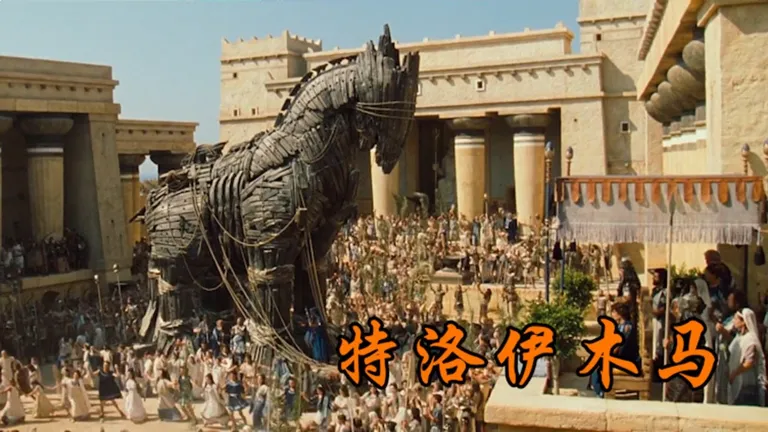
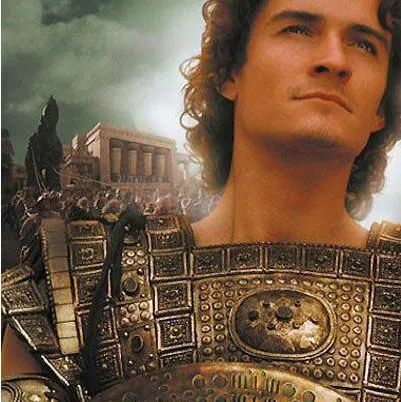
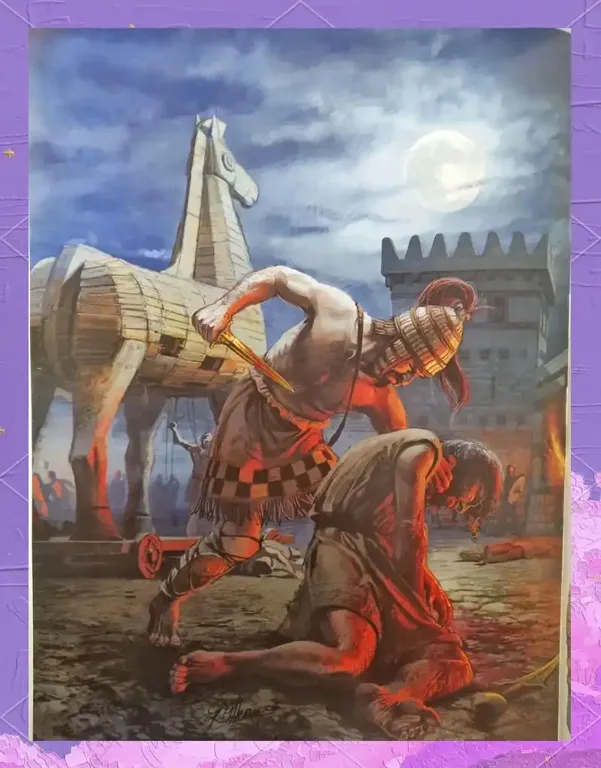
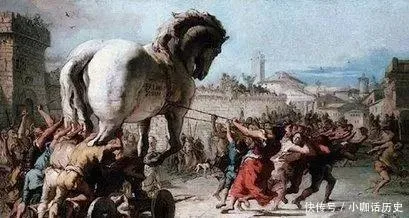
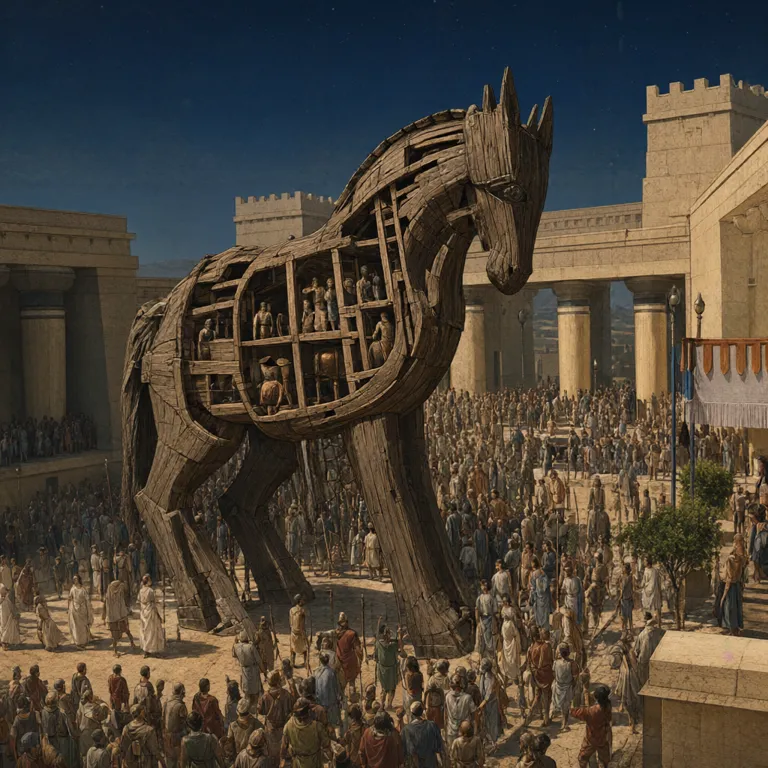

In [1]:
# 只读查看：本格可独立运行；仅写本地浏览页，不调用模型、不修改结果表。
from pathlib import Path
import sys
from IPython.display import HTML, display

PROJECT = next(p for p in (Path.cwd(), *Path.cwd().parents, Path.cwd() / 'demiwtg')
               if (p / 'project.py').exists())
for path in (PROJECT, PROJECT.parent / 'demiflow'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
from benchmark.edit.v2.operators.case_viewer import build_case_browser, notebook_browser

VIEW_RUN_ID = 'edit_e2e10_v1_20261004'
document, view_metadata = build_case_browser(PROJECT, VIEW_RUN_ID)
viewer_path = PROJECT / 'benchmark/edit/v2/runs' / VIEW_RUN_ID / 'case_browser.html'
viewer_path.parent.mkdir(parents=True, exist_ok=True)
viewer_temporary = viewer_path.with_suffix('.html.tmp')
viewer_temporary.write_text(document)
viewer_temporary.replace(viewer_path)
display(HTML(notebook_browser(document, f'runs/{VIEW_RUN_ID}/case_browser.html', height=1500)))
